##

because 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os.path as op
import os
import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder_orig = '/mnt_03/ds-dnumrisk' 

In [3]:
grad_n = 2

oldConf_NPCdisper = pd.read_csv(op.join(bids_folder_orig, 'derivatives', 'phenotype',f'withinNdispersion-NPC_grad-{grad_n}.csv' )).set_index('subject')

confspec = '32Pscrub3BPfilterrunFD104'
newConf32_NPCdisper = pd.read_csv(op.join(bids_folder_orig, 'derivatives', 'phenotype',f'withinNdispersion-NPC_grad-{grad_n}_confspec-{confspec}.csv' )).set_index('subject').sort_index()

confspec = '36Pscrub3BPfilterrunFD104'
newConf36_NPCdisper = pd.read_csv(op.join(bids_folder_orig, 'derivatives', 'phenotype',f'withinNdispersion-NPC_grad-{grad_n}_confspec-{confspec}.csv' )).set_index('subject').sort_index()
print(newConf36_NPCdisper.sort_index())

         group  NPC_dispersion  NPC_centroid
subject                                     
1            0        2.193481      2.191812
2            1        2.765502     -0.858289
3            0        2.402229      0.290897
4            1       12.034594      0.136258
5            0        4.957668     -0.518192
...        ...             ...           ...
62           0        6.969186      1.347810
63           0        2.153543     -0.129615
64           0    35655.870579  -9664.613396
65           0        5.278967     -0.294583
66           0        2.020192      0.516725

[66 rows x 3 columns]


In [13]:
comparison_df = oldConf_NPCdisper[['NPC_dispersion']].rename(columns={'NPC_dispersion': 'oldConf'}).join(
    newConf32_NPCdisper[['NPC_dispersion']].rename(columns={'NPC_dispersion': 'newConf_32'})).join(
    newConf36_NPCdisper[['NPC_dispersion']].rename(columns={'NPC_dispersion': 'newConf_36'}))
comparison_df.sort_index()

,oldConf,newConf_32,newConf_36
subject,,,
1,7.300665,1.985013,2.193481
2,4.660234,2.406880,2.765502
3,2.410949,1.771344,2.402229
4,10.872834,6.628588,12.034594
5,4.050231,3.659803,4.957668
...,...,...,...
62,12.886451,5.824030,6.969186
63,1.964317,1.323412,2.153543
64,2.335654,3.307033,35655.870579


In [14]:
comparison_df.drop(6).drop(64).corr()

,oldConf,newConf_32,newConf_36
oldConf,1.000000,0.803932,0.750478
newConf_32,0.803932,1.000000,0.930457
newConf_36,0.750478,0.930457,1.000000


In [15]:
melted_df = comparison_df.reset_index().melt(id_vars='subject', var_name='Confounds', value_name='NPC_dispersion')
melted_df = melted_df.set_index('subject').join(oldConf_NPCdisper['group'])
melted_df

,Confounds,NPC_dispersion,group
subject,,,
21,oldConf,11.874677,0
59,oldConf,2.687693,0
54,oldConf,6.611221,0
15,oldConf,15.730722,0
52,oldConf,3.709795,0
...,...,...,...
28,newConf_36,2.049183,0
42,newConf_36,5.012089,1
25,newConf_36,4.685295,1


In [16]:
sns.set_context("talk")

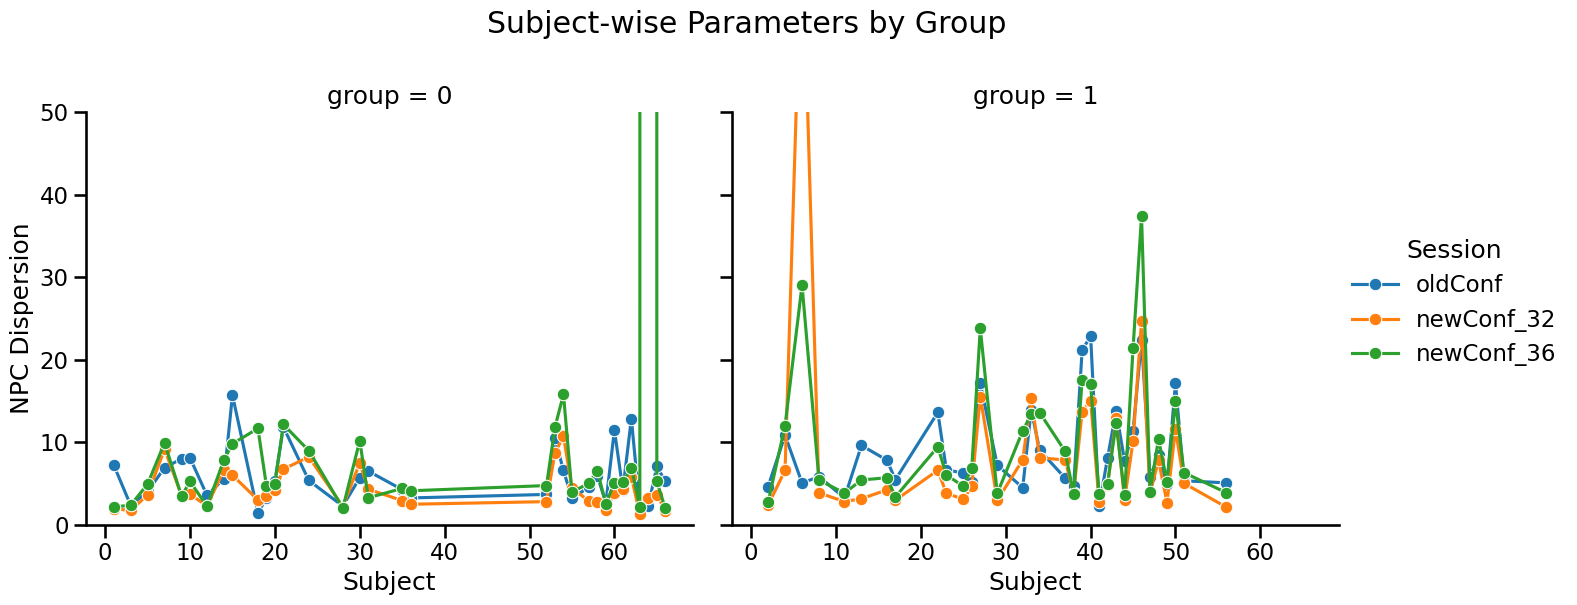

In [17]:
# Plot using Seaborn with separate columns for groups and connected lines
g = sns.FacetGrid(
    data=melted_df.reset_index(),
    col="group",  # Separate columns for each group
    hue="Confounds",
    palette="tab10",
    height=6,
    aspect=1.2
)

# Add line plots to the grid
g.map(sns.lineplot, "subject", "NPC_dispersion", marker="o")

# Adjust the layout and add a title
g.add_legend(title="Session")
g.set_axis_labels("Subject", "NPC Dispersion")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Subject-wise Parameters by Group", y=1.02)
g.set(ylim=(0, 50))



In [23]:
tmp = melted_df.drop(64)
print(tmp.set_index('Confounds',append=True).groupby('Confounds').std())
tmp.set_index('Confounds',append=True).groupby('Confounds').mean()

            NPC_dispersion     group
Confounds                           
newConf_32        9.395090  0.503831
newConf_36        6.634793  0.503831
oldConf           4.895767  0.503831


,NPC_dispersion,group
Confounds,,
newConf_32,6.763489,0.507692
newConf_36,8.139036,0.507692
oldConf,7.620203,0.507692
